In [1]:
import pandas as pd
from pathlib import Path


In [2]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT / 'data'


In [3]:
accounts_df = pd.read_csv(DATA_DIR / 'accounts.csv')
sar_accounts_df = pd.read_csv(DATA_DIR / 'sar_accounts.csv')
tx_count_df = pd.read_csv(DATA_DIR / 'tx_count.csv')
tx_log_df = pd.read_csv(DATA_DIR / 'tx_log.csv')


In [4]:
accounts_df.head()


,acct_id,dsply_nm,type,acct_stat,acct_rptng_crncy,prior_sar_count,branch_id,open_dt,close_dt,initial_deposit,...,street_addr,city,state,country,zip,gender,birth_date,ssn,lon,lat
0,0,C_0,I,A,USD,True,1,0,1000000,567879.30,...,48764 Howard Forge Apt. 421,Vanessaside,VT,US,79393,Male,2009-10-14,076-88-5410,73.479690,60.273842
1,1,C_1,I,A,USD,False,1,0,1000000,522617.73,...,9387 Grimes Green Apt. 801,Pagetown,RI,US,65195,Female,2009-11-05,334-91-1032,-77.421639,62.340004
2,2,C_2,I,A,USD,True,1,0,1000000,622279.17,...,711 Golden Overpass,West Andreaville,OH,US,44115,Male,2019-04-04,618-71-9628,-25.565183,29.450832
3,3,C_3,I,A,USD,False,1,0,1000000,722426.10,...,9342 Lori Bypass Suite 711,East Sandra,MP,US,11019,Female,1984-01-12,700-51-8595,-32.020057,50.066962
4,4,C_4,I,A,USD,True,1,0,1000000,707402.13,...,969 Hayes Shore,Christopherville,NM,US,77450,Male,1943-07-14,017-94-4441,-117.114006,-30.820575


In [5]:
accounts_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12043 entries, 0 to 12042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acct_id           12043 non-null  int64  
 1   dsply_nm          12043 non-null  object 
 2   type              12043 non-null  object 
 3   acct_stat         12043 non-null  object 
 4   acct_rptng_crncy  12043 non-null  object 
 5   prior_sar_count   12043 non-null  bool   
 6   branch_id         12043 non-null  int64  
 7   open_dt           12043 non-null  int64  
 8   close_dt          12043 non-null  int64  
 9   initial_deposit   12043 non-null  float64
 10  tx_behavior_id    0 non-null      float64
 11  bank_id           12043 non-null  object 
 12  first_name        12043 non-null  object 
 13  last_name         12043 non-null  object 
 14  street_addr       12043 non-null  object 
 15  city              12043 non-null  object 
 16  state             12043 non-null  object

In [6]:
accounts_df.isnull().sum()[accounts_df.isnull().sum() > 0]

tx_behavior_id    12043
dtype: int64

## tx_log

In [7]:
tx_log_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896914 entries, 0 to 896913
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            896914 non-null  int64  
 1   type            896914 non-null  object 
 2   amount          896914 non-null  float64
 3   nameOrig        896914 non-null  int64  
 4   oldbalanceOrig  896914 non-null  float64
 5   newbalanceOrig  896914 non-null  float64
 6   nameDest        896914 non-null  int64  
 7   oldbalanceDest  896914 non-null  float64
 8   newbalanceDest  896914 non-null  float64
 9   isSAR           896914 non-null  int64  
 10  alertID         896914 non-null  int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 75.3+ MB


In [8]:
tx_log_df.isnull().sum()[tx_log_df.isnull().sum() > 0]

Series([], dtype: int64)

In [9]:
tx_log_df['type'].value_counts()

type
TRANSFER    896914
Name: count, dtype: int64

In [10]:
tx_log_df['isSAR'].value_counts()

isSAR
0    889679
1      7235
Name: count, dtype: int64

## sar_accounts

In [11]:
sar_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7615 entries, 0 to 7614
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ALERT_ID      7615 non-null   int64 
 1   ACCOUNT_ID    7615 non-null   int64 
 2   CUSTOMER_ID   7615 non-null   object
 3   EVENT_DATE    7615 non-null   int64 
 4   ALERT_TYPE    7615 non-null   object
 5   ACCOUNT_TYPE  7615 non-null   object
 6   IS_SAR        7615 non-null   object
dtypes: int64(3), object(4)
memory usage: 416.6+ KB


In [12]:
sar_accounts_df['IS_SAR'].value_counts()

IS_SAR
YES    7615
Name: count, dtype: int64

In [13]:
sar_accounts_df['ALERT_TYPE'].value_counts()

ALERT_TYPE
cycle             2514
fan_in            1796
fan_out           1662
scatter_gather     895
gather_scatter     748
Name: count, dtype: int64

## Amount Distributions

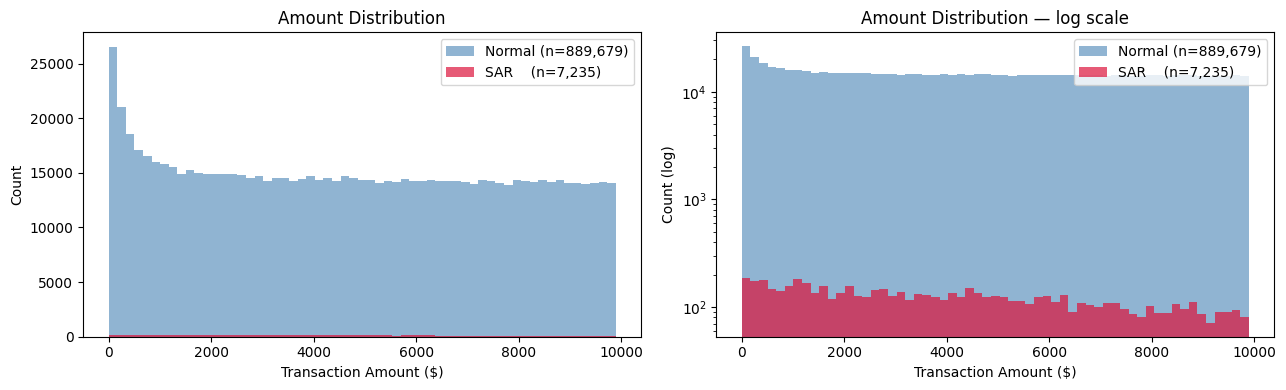

          count     mean      std   min      25%      50%      75%      max
isSAR                                                                      
0      889679.0  4797.51  2956.58  0.04  2184.25  4746.39  7361.48  9999.99
1        7235.0  4434.12  2860.30  0.08  1915.26  4224.44  6757.28  9999.43


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

sar_amounts = tx_log_df.loc[tx_log_df['isSAR'] == 1, 'amount']
normal_amounts = tx_log_df.loc[tx_log_df['isSAR'] == 0, 'amount']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0, tx_log_df['amount'].quantile(0.99), 60)

for ax, log in zip(axes, [False, True]):
    ax.hist(normal_amounts, bins=bins, alpha=0.6, label=f'Normal (n={len(normal_amounts):,})', color='steelblue')
    ax.hist(sar_amounts,    bins=bins, alpha=0.7, label=f'SAR    (n={len(sar_amounts):,})',    color='crimson')
    ax.set_xlabel('Transaction Amount ($)')
    ax.set_ylabel('Count' + (' (log)' if log else ''))
    ax.set_title('Amount Distribution' + (' — log scale' if log else ''))
    ax.legend()
    if log:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

print(tx_log_df.groupby('isSAR')['amount'].describe().round(2))

## Per-Account Transaction Counts

Outgoing tx count per account:
         count   mean   std  min    25%    50%    75%    max
is_sar                                                      
Normal  2831.0  109.9  75.3  1.0  102.0  104.0  161.0  412.0
SAR     6887.0   85.0  84.8  1.0    1.0  104.0  142.0  414.0


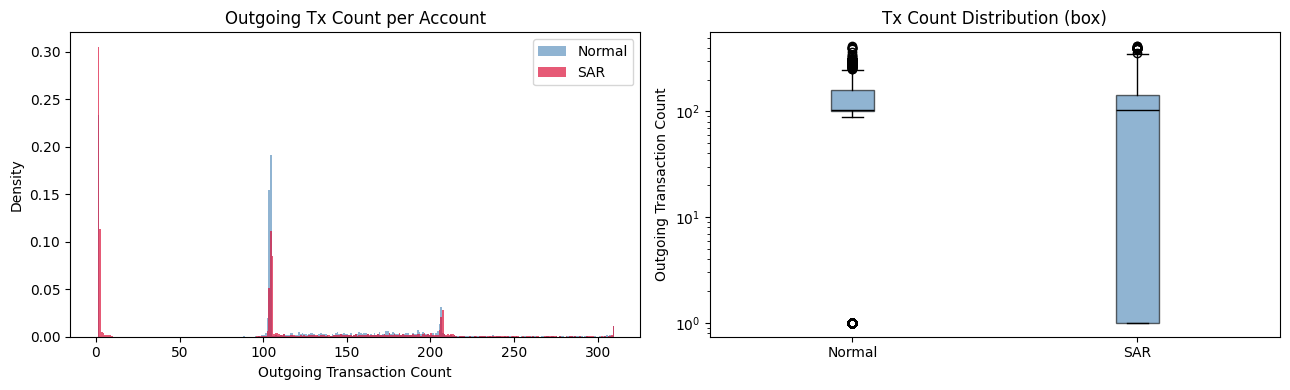

In [15]:
sar_acct_ids = set(sar_accounts_df['ACCOUNT_ID'])

# Count outgoing transactions per account (nameOrig = sender)
tx_per_acct = tx_log_df.groupby('nameOrig').size().rename('tx_count')
tx_per_acct = tx_per_acct.to_frame()
tx_per_acct['is_sar'] = tx_per_acct.index.isin(sar_acct_ids)

sar_counts    = tx_per_acct.loc[tx_per_acct['is_sar'],  'tx_count']
normal_counts = tx_per_acct.loc[~tx_per_acct['is_sar'], 'tx_count']

print("Outgoing tx count per account:")
print(tx_per_acct.groupby('is_sar')['tx_count'].describe().round(1).rename(index={False: 'Normal', True: 'SAR'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cap = int(tx_per_acct['tx_count'].quantile(0.99))
bins = range(0, cap + 2)

axes[0].hist(normal_counts.clip(upper=cap), bins=bins, alpha=0.6, label='Normal', color='steelblue', density=True)
axes[0].hist(sar_counts.clip(upper=cap),    bins=bins, alpha=0.7, label='SAR',    color='crimson',   density=True)
axes[0].set_xlabel('Outgoing Transaction Count')
axes[0].set_ylabel('Density')
axes[0].set_title('Outgoing Tx Count per Account')
axes[0].legend()

axes[1].boxplot([normal_counts, sar_counts], tick_labels=['Normal', 'SAR'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black'))
axes[1].set_ylabel('Outgoing Transaction Count')
axes[1].set_title('Tx Count Distribution (box)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Transaction Volume Over Time

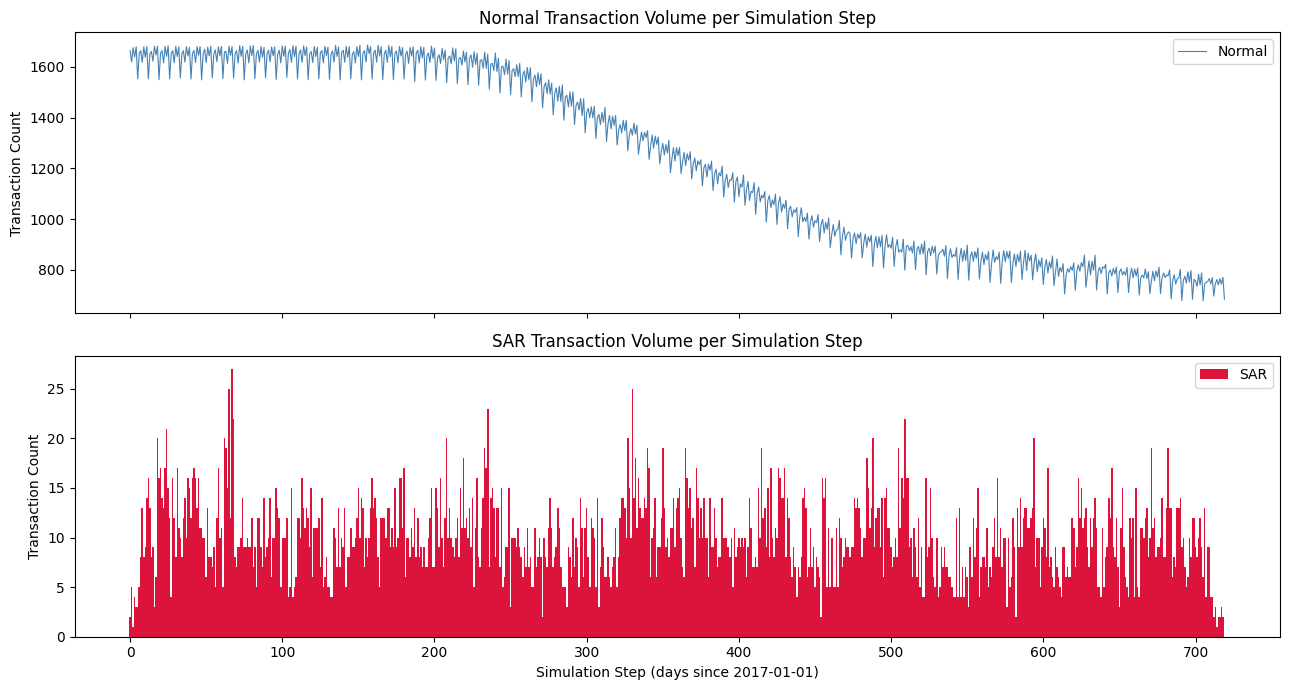

Steps with zero SAR transactions: 1 / 720
Max SAR transactions on a single step: 27 (step 67)


In [16]:
all_steps = pd.Series(range(tx_log_df['step'].max() + 1))

normal_by_step = tx_log_df[tx_log_df['isSAR'] == 0].groupby('step').size().reindex(all_steps, fill_value=0)
sar_by_step    = tx_log_df[tx_log_df['isSAR'] == 1].groupby('step').size().reindex(all_steps, fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(normal_by_step.index, normal_by_step.values, color='steelblue', linewidth=0.8, label='Normal')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Normal Transaction Volume per Simulation Step')
axes[0].legend()

axes[1].bar(sar_by_step.index, sar_by_step.values, color='crimson', width=1.0, label='SAR')
axes[1].set_xlabel('Simulation Step (days since 2017-01-01)')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('SAR Transaction Volume per Simulation Step')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Steps with zero SAR transactions: {(sar_by_step == 0).sum()} / {len(sar_by_step)}")
print(f"Max SAR transactions on a single step: {sar_by_step.max()} (step {sar_by_step.idxmax()})")

## Graph Degree Distribution

Graph: 11,029 nodes, 51,445 edges

In-degree summary:
       Normal     SAR
count  3414.0  7615.0
mean      3.0     5.4
std      22.5    30.6
min       0.0     0.0
25%       0.0     1.0
50%       0.0     1.0
75%       1.0     2.0
max     526.0   524.0

Out-degree summary:
       Normal     SAR
count  3414.0  7615.0
mean      3.5     5.2
std      11.4    14.1
min       0.0     0.0
25%       1.0     1.0
50%       1.0     2.0
75%       2.0     3.0
max     103.0   111.0


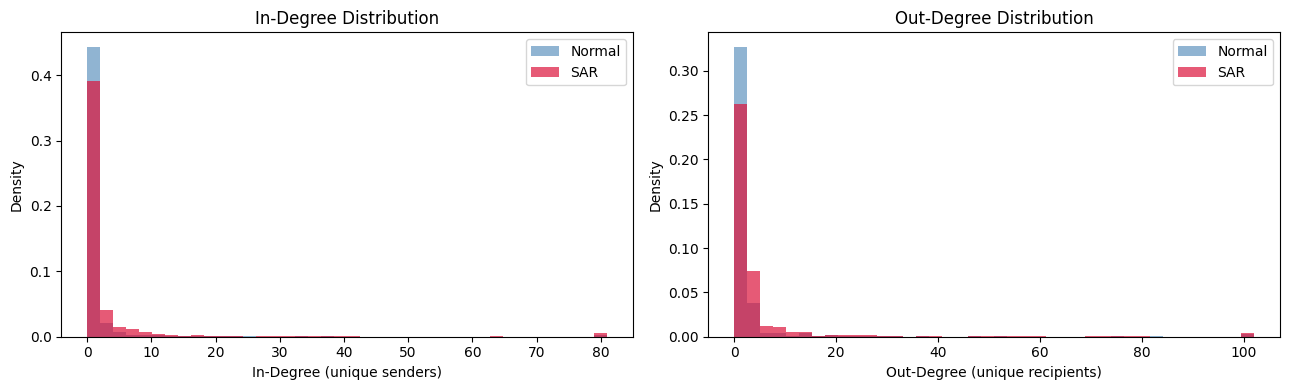

In [17]:
import networkx as nx

G = nx.from_pandas_edgelist(
    tx_log_df, source='nameOrig', target='nameDest',
    create_using=nx.DiGraph()
)

in_deg  = pd.Series(dict(G.in_degree()),  name='in_degree')
out_deg = pd.Series(dict(G.out_degree()), name='out_degree')

in_deg_sar  = in_deg[in_deg.index.isin(sar_acct_ids)]
in_deg_norm = in_deg[~in_deg.index.isin(sar_acct_ids)]
out_deg_sar  = out_deg[out_deg.index.isin(sar_acct_ids)]
out_deg_norm = out_deg[~out_deg.index.isin(sar_acct_ids)]

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print()
print("In-degree summary:")
print(pd.DataFrame({'Normal': in_deg_norm.describe(), 'SAR': in_deg_sar.describe()}).round(1))
print()
print("Out-degree summary:")
print(pd.DataFrame({'Normal': out_deg_norm.describe(), 'SAR': out_deg_sar.describe()}).round(1))

cap_in  = int(in_deg.quantile(0.99))
cap_out = int(out_deg.quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(in_deg_norm.clip(upper=cap_in), bins=40, alpha=0.6, density=True, label='Normal', color='steelblue')
axes[0].hist(in_deg_sar.clip(upper=cap_in),  bins=40, alpha=0.7, density=True, label='SAR',    color='crimson')
axes[0].set_xlabel('In-Degree (unique senders)')
axes[0].set_ylabel('Density')
axes[0].set_title('In-Degree Distribution')
axes[0].legend()

axes[1].hist(out_deg_norm.clip(upper=cap_out), bins=40, alpha=0.6, density=True, label='Normal', color='steelblue')
axes[1].hist(out_deg_sar.clip(upper=cap_out),  bins=40, alpha=0.7, density=True, label='SAR',    color='crimson')
axes[1].set_xlabel('Out-Degree (unique recipients)')
axes[1].set_ylabel('Density')
axes[1].set_title('Out-Degree Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## AML Pattern Subgraphs (Graphviz)

One example subgraph per typology, rendered as a directed graph. Each node is an account; edge labels show the transaction amount.

── fan_in  (alert_id=0) ──────────────────


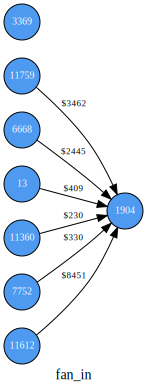

── fan_out  (alert_id=260) ──────────────────


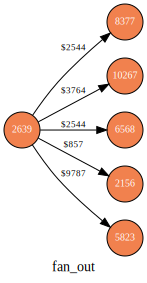

── cycle  (alert_id=520) ──────────────────


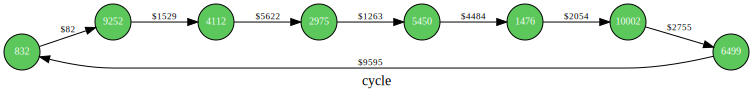

── scatter_gather  (alert_id=870) ──────────────────


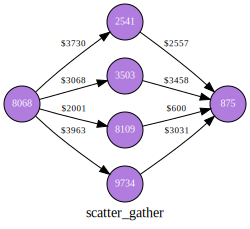

── gather_scatter  (alert_id=990) ──────────────────


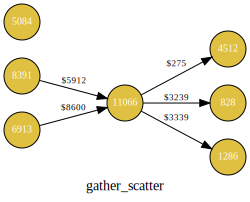

In [18]:
import graphviz
from IPython.display import display

alert_tx   = pd.read_csv(DATA_DIR / 'aux/alert_transactions.csv')
alert_accts = pd.read_csv(DATA_DIR / 'aux/alert_accounts.csv')

TYPOLOGY_COLORS = {
    'fan_in':        '#4e9af1',
    'fan_out':       '#f1814e',
    'cycle':         '#5cc85c',
    'scatter_gather':'#b07cde',
    'gather_scatter':'#e0c040',
}

def render_alert(alert_id: int, typology: str) -> graphviz.Digraph:
    txs   = alert_tx[alert_tx['alert_id'] == alert_id]
    accts = alert_accts[alert_accts['alert_id'] == alert_id]

    color = TYPOLOGY_COLORS.get(typology, '#aaaaaa')
    dot = graphviz.Digraph(
        name=typology,
        graph_attr={'rankdir': 'LR', 'label': typology, 'fontsize': '14', 'bgcolor': 'white'},
        node_attr={'shape': 'circle', 'style': 'filled', 'fillcolor': color,
                   'fontcolor': 'white', 'fontsize': '10', 'width': '0.5', 'fixedsize': 'true'},
        edge_attr={'fontsize': '9'},
    )
    for acct_id in accts['acct_id'].unique():
        dot.node(str(acct_id), str(acct_id))
    for _, row in txs.iterrows():
        dot.edge(str(row['orig_acct']), str(row['bene_acct']), label=f"${row['base_amt']:.0f}")
    return dot

for typology in ['fan_in', 'fan_out', 'cycle', 'scatter_gather', 'gather_scatter']:
    example_id = alert_accts[alert_accts['alert_type'] == typology]['alert_id'].iloc[0]
    print(f"── {typology}  (alert_id={example_id}) ──────────────────")
    display(render_alert(example_id, typology))